In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from datetime import timedelta
from netCDF4 import Dataset, date2num, num2date
import cftime
import glob
import os
import csv
%matplotlib inline
import datetime
import matplotlib.dates as mdates
import matplotlib.dates as md
import metpy.calc as mpcalc
from metpy.units import units
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator

files_swats = sorted(glob.glob('/Users/dave121504/ARM Project/SWATS Files/sgpswats*.nc'))
swats = xr.open_mfdataset(files_swats, combine='by_coords')

files_stamp = sorted(glob.glob('/Users/dave121504/ARM Project/STAMP Files/sgpstamp*.nc'))
stamp = xr.open_mfdataset(files_stamp, combine='by_coords')

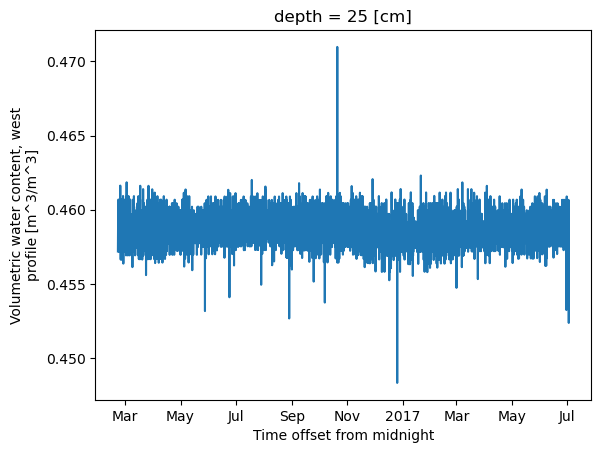

In [3]:
swats['watcont_w'].isel(depth=2).plot()

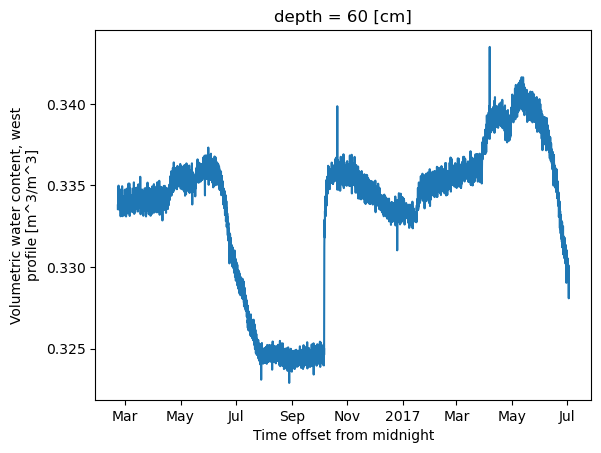

In [4]:
swats['watcont_w'].isel(depth=4).plot()

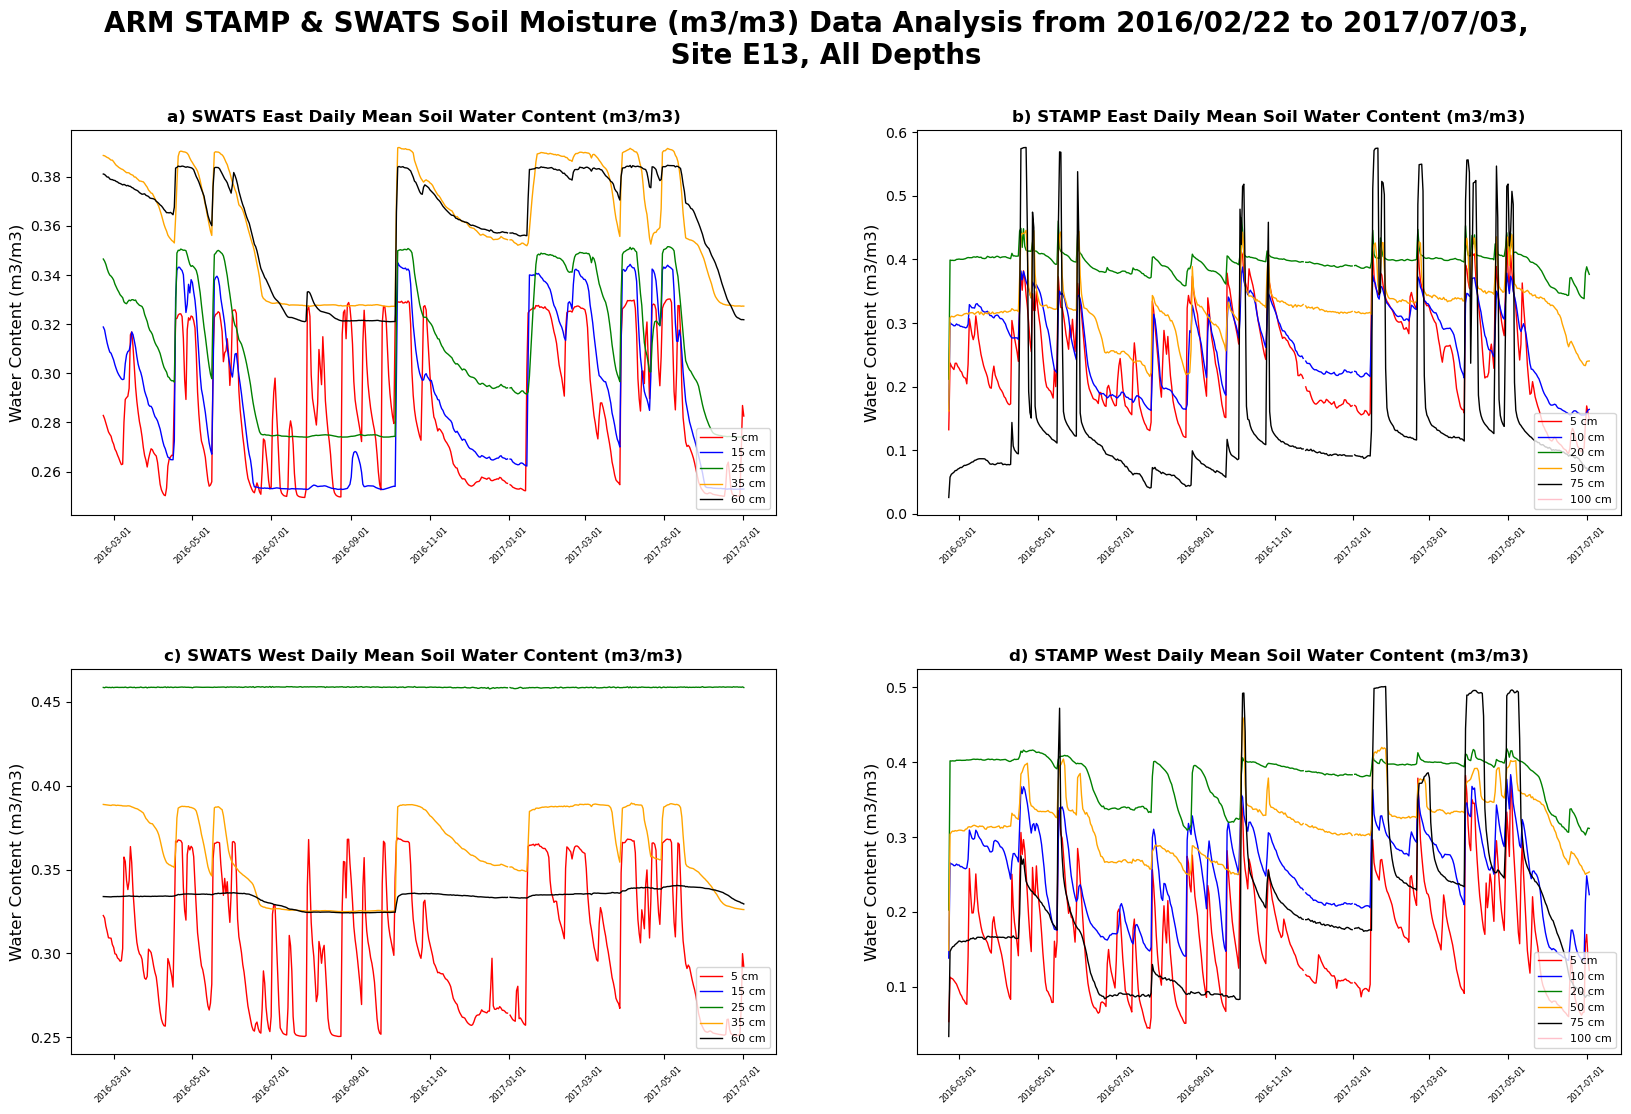

In [5]:
fig, axes = plt.subplots(2, 2, figsize = (20, 12))

time_swats = swats['time']
time_stamp = stamp['time']


#SWATS EAST#

#5cm
swats_spec_moist_E_5 = swats['watcont_e'].isel(depth=0)
swats_daily_moist_E_5 = swats_spec_moist_E_5.resample(time = '1D').mean()
#15cm
swats_spec_moist_E_15 = swats['watcont_e'].isel(depth=1)
swats_daily_moist_E_15 = swats_spec_moist_E_15.resample(time = '1D').mean()
#25cm
swats_spec_moist_E_25 = swats['watcont_e'].isel(depth=2)
swats_daily_moist_E_25 = swats_spec_moist_E_25.resample(time = '1D').mean()
#35cm
swats_spec_moist_E_35 = swats['watcont_e'].isel(depth=3)
swats_daily_moist_E_35 = swats_spec_moist_E_35.resample(time = '1D').mean()
#60cm
swats_spec_moist_E_60 = swats['watcont_e'].isel(depth=4)
swats_daily_moist_E_60 = swats_spec_moist_E_60.resample(time = '1D').mean()

#East SWATS moisture, plot a
axes[0,0].plot(swats_daily_moist_E_5['time'], swats_daily_moist_E_5, color = 'red', linewidth = 1, label = '5 cm')
axes[0,0].plot(swats_daily_moist_E_15['time'], swats_daily_moist_E_15, color = 'blue', linewidth = 1, label = '15 cm')
axes[0,0].plot(swats_daily_moist_E_25['time'], swats_daily_moist_E_25, color = 'green', linewidth = 1, label = '25 cm')
axes[0,0].plot(swats_daily_moist_E_35['time'], swats_daily_moist_E_35, color = 'orange', linewidth = 1, label = '35 cm')
axes[0,0].plot(swats_daily_moist_E_60['time'], swats_daily_moist_E_60, color = 'black', linewidth = 1, label = '60 cm')
axes[0,0].set_ylabel('Water Content (m3/m3)', fontsize = 12)
axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
axes[0,0].tick_params(axis = 'x', labelrotation = 45, labelsize = 6)
axes[0,0].set_title("a) SWATS East Daily Mean Soil Water Content (m3/m3)", fontweight = 'bold', fontsize = 12)
axes[0,0].legend(loc = "lower right", fontsize = 8)


#STAMP East
#5cm
stamp_spec_moist_E_5 = stamp['soil_specific_water_content_east'].isel(depth=0)
stamp_daily_moist_E_5 = stamp_spec_moist_E_5.resample(time = '1D').mean()
#10cm
stamp_spec_moist_E_10 = stamp['soil_specific_water_content_east'].isel(depth=1)
stamp_daily_moist_E_10 = stamp_spec_moist_E_10.resample(time = '1D').mean()
#20cm
stamp_spec_moist_E_20 = stamp['soil_specific_water_content_east'].isel(depth=2)
stamp_daily_moist_E_20 = stamp_spec_moist_E_20.resample(time = '1D').mean()
#50cm
stamp_spec_moist_E_50 = stamp['soil_specific_water_content_east'].isel(depth=3)
stamp_daily_moist_E_50 = stamp_spec_moist_E_50.resample(time = '1D').mean()
#75cm
stamp_spec_moist_E_75 = stamp['soil_specific_water_content_east'].isel(depth=4)
stamp_daily_moist_E_75 = stamp_spec_moist_E_75.resample(time = '1D').mean()
#100cm
stamp_spec_moist_E_100 = stamp['soil_specific_water_content_east'].isel(depth=5)
stamp_daily_moist_E_100 = stamp_spec_moist_E_100.resample(time = '1D').mean()

#make into decimals (m3/m3)
stamp_moist_E_5 = stamp_daily_moist_E_5 / 100
stamp_moist_E_10 = stamp_daily_moist_E_10 / 100
stamp_moist_E_20 = stamp_daily_moist_E_20 / 100
stamp_moist_E_50 = stamp_daily_moist_E_50 / 100
stamp_moist_E_75 = stamp_daily_moist_E_75 / 100
stamp_moist_E_100 = stamp_daily_moist_E_100 / 100


#East SWATS moisture, plot a
axes[0,1].plot(stamp_moist_E_5['time'], stamp_moist_E_5, color = 'red', linewidth = 1, label = '5 cm')
axes[0,1].plot(stamp_moist_E_10['time'], stamp_moist_E_10, color = 'blue', linewidth = 1, label = '10 cm')
axes[0,1].plot(stamp_moist_E_20['time'], stamp_moist_E_20, color = 'green', linewidth = 1, label = '20 cm')
axes[0,1].plot(stamp_moist_E_50['time'], stamp_moist_E_50, color = 'orange', linewidth = 1, label = '50 cm')
axes[0,1].plot(stamp_moist_E_75['time'], stamp_moist_E_75, color = 'black', linewidth = 1, label = '75 cm')
axes[0,1].plot(stamp_moist_E_100['time'], stamp_moist_E_100, color = 'pink', linewidth = 1, label = '100 cm')
axes[0,1].set_ylabel('Water Content (m3/m3)', fontsize = 12)
axes[0,1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
axes[0,1].tick_params(axis = 'x', labelrotation = 45, labelsize = 6)
axes[0,1].set_title("b) STAMP East Daily Mean Soil Water Content (m3/m3)", fontweight = 'bold', fontsize = 12)
axes[0,1].legend(loc = "lower right", fontsize = 8)



#SWATS WEST#

#5cm
swats_spec_moist_W_5 = swats['watcont_w'].isel(depth=0)
swats_daily_moist_W_5 = swats_spec_moist_W_5.resample(time = '1D').mean()
#15cm
swats_spec_moist_W_15 = swats['watcont_w'].isel(depth=1)
swats_daily_moist_W_15 = swats_spec_moist_W_15.resample(time = '1D').mean()
#25cm
swats_spec_moist_W_25 = swats['watcont_w'].isel(depth=2)
swats_daily_moist_W_25 = swats_spec_moist_W_25.resample(time = '1D').mean()
#35cm
swats_spec_moist_W_35 = swats['watcont_w'].isel(depth=3)
swats_daily_moist_W_35 = swats_spec_moist_W_35.resample(time = '1D').mean()
#60cm
swats_spec_moist_W_60 = swats['watcont_w'].isel(depth=4)
swats_daily_moist_W_60 = swats_spec_moist_W_60.resample(time = '1D').mean()

#West SWATS moisture, plot c
axes[1,0].plot(swats_daily_moist_W_5['time'], swats_daily_moist_W_5, color = 'red', linewidth = 1, label = '5 cm')
axes[1,0].plot(swats_daily_moist_W_15['time'], swats_daily_moist_W_15, color = 'blue', linewidth = 1, label = '15 cm')
axes[1,0].plot(swats_daily_moist_W_25['time'], swats_daily_moist_W_25, color = 'green', linewidth = 1, label = '25 cm')
axes[1,0].plot(swats_daily_moist_W_35['time'], swats_daily_moist_W_35, color = 'orange', linewidth = 1, label = '35 cm')
axes[1,0].plot(swats_daily_moist_W_60['time'], swats_daily_moist_W_60, color = 'black', linewidth = 1, label = '60 cm')
axes[1,0].set_ylabel('Water Content (m3/m3)', fontsize = 12)
axes[1,0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
axes[1,0].tick_params(axis = 'x', labelrotation = 45, labelsize = 6)
axes[1,0].set_title("c) SWATS West Daily Mean Soil Water Content (m3/m3)", fontweight = 'bold', fontsize = 12)
axes[1,0].legend(loc = "lower right", fontsize = 8)


#STAMP West
#5cm
stamp_spec_moist_W_5 = stamp['soil_specific_water_content_west'].isel(depth=0)
stamp_daily_moist_W_5 = stamp_spec_moist_W_5.resample(time = '1D').mean()
#10cm
stamp_spec_moist_W_10 = stamp['soil_specific_water_content_west'].isel(depth=1)
stamp_daily_moist_W_10 = stamp_spec_moist_W_10.resample(time = '1D').mean()
#20cm
stamp_spec_moist_W_20 = stamp['soil_specific_water_content_west'].isel(depth=2)
stamp_daily_moist_W_20 = stamp_spec_moist_W_20.resample(time = '1D').mean()
#50cm
stamp_spec_moist_W_50 = stamp['soil_specific_water_content_west'].isel(depth=3)
stamp_daily_moist_W_50 = stamp_spec_moist_W_50.resample(time = '1D').mean()
#75cm
stamp_spec_moist_W_75 = stamp['soil_specific_water_content_west'].isel(depth=4)
stamp_daily_moist_W_75 = stamp_spec_moist_W_75.resample(time = '1D').mean()
#100cm
stamp_spec_moist_W_100 = stamp['soil_specific_water_content_west'].isel(depth=5)
stamp_daily_moist_W_100 = stamp_spec_moist_W_100.resample(time = '1D').mean()

#make into decimals (m3/m3)
stamp_moist_W_5 = stamp_daily_moist_W_5 / 100
stamp_moist_W_10 = stamp_daily_moist_W_10 / 100
stamp_moist_W_20 = stamp_daily_moist_W_20 / 100
stamp_moist_W_50 = stamp_daily_moist_W_50 / 100
stamp_moist_W_75 = stamp_daily_moist_W_75 / 100
stamp_moist_W_100 = stamp_daily_moist_W_100 / 100


#East SWATS moisture, plot a
axes[1,1].plot(stamp_moist_W_5['time'], stamp_moist_W_5, color = 'red', linewidth = 1, label = '5 cm')
axes[1,1].plot(stamp_moist_W_10['time'], stamp_moist_W_10, color = 'blue', linewidth = 1, label = '10 cm')
axes[1,1].plot(stamp_moist_W_20['time'], stamp_moist_W_20, color = 'green', linewidth = 1, label = '20 cm')
axes[1,1].plot(stamp_moist_W_50['time'], stamp_moist_W_50, color = 'orange', linewidth = 1, label = '50 cm')
axes[1,1].plot(stamp_moist_W_75['time'], stamp_moist_W_75, color = 'black', linewidth = 1, label = '75 cm')
axes[1,1].plot(stamp_moist_W_100['time'], stamp_moist_W_100, color = 'pink', linewidth = 1, label = '100 cm')
axes[1,1].set_ylabel('Water Content (m3/m3)', fontsize = 12)
axes[1,1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
axes[1,1].tick_params(axis = 'x', labelrotation = 45, labelsize = 6)
axes[1,1].set_title("d) STAMP West Daily Mean Soil Water Content (m3/m3)", fontweight = 'bold', fontsize = 12)
axes[1,1].legend(loc = "lower right", fontsize = 8)

fig.suptitle(f"ARM STAMP & SWATS Soil Moisture (m3/m3) Data Analysis from 2016/02/22 to 2017/07/03, \n Site E13, All Depths", fontweight = 'bold', fontsize = 20)           
plt.subplots_adjust(hspace=0.4, wspace = 0.2)
plt.savefig('ARM_soil_moisture_analysis_all_depths.png', dpi=300, bbox_inches='tight')


